<a href="https://colab.research.google.com/github/CookieNtoo/TestCode99/blob/main/Tor_non.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#eisagogi paketwn
!pip install pandas scikit-learn sqlalchemy

In [ ]:
#stellantousia@mbp-stella askisi_ml % cat dataset.csv | awk -F "," '{print $82}' | sort | uniq -c | sort -rn
#30931 Non-Tor
#22740 NonVPN
#13517 VPN
#1392 Tor
#   1 Label-1
#stellantousia@mbp-stella askisi_ml % cat dataset.csv | awk -F "," '{print $83}' | sort | uniq -c | sort -rn
#13711 P2P
#11478 Chat
#11098 File-Transfer
#9486 Video-Streaming
#6145 Email
#6055 Audio-Streaming
#5192 Browsing
#3566 VOIP
#1484 AUDIO-STREAMING
# 281 Video-streaming
#  84 File-transfer
#   1 Label-2
## poies efarmoges xrhsimopoioun TOR
#stella askisi_ml % cat dataset.csv | grep ',Tor' | awk -F "," '{print $83}' | sort | uniq -c | sort -rn
# 298 VOIP
# 263 Browsing
# 224 Audio-Streaming
# 220 P2P
# 202 Video-Streaming
# 107 File-Transfer
#  65 Chat
#  13 Email
## poies efarmoges xrhsimopoioun to VPN
#stellantousia@mbp-stella askisi_ml % cat dataset.csv | grep ',VPN' | awk -F "," '{print $83}' | sort | uniq -c | sort -rn
#4476 Chat
#3658 Audio-Streaming
#2503 File-Transfer
#1167 VOIP
#1144 Video-Streaming
# 569 Email
#

In [2]:
#eisagogi vivliothikwn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

Πρώτο βήμα είναι να δούμε τα δεδομένα μας.

In [3]:
train_data = pd.read_csv('https://raw.githubusercontent.com/kdemertzis/EKPA/refs/heads/main/Data/DarkNet.csv')
train_data.describe()
train_data.info()

<ipython-input-3-d61e40a57bfc>:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('https://raw.githubusercontent.com/kdemertzis/EKPA/refs/heads/main/Data/DarkNet.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68580 entries, 0 to 68579
Data columns (total 83 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Src_IP                      68580 non-null  object 
 1   Src_Port                    68580 non-null  int64  
 2   Dst_IP                      68580 non-null  object 
 3   Dst_Port                    68580 non-null  int64  
 4   Protocol                    68580 non-null  int64  
 5   Flow_Duration               68580 non-null  int64  
 6   Total_Fwd_Packet            68580 non-null  int64  
 7   Total_Bwd_packets           68580 non-null  int64  
 8   Total_Length_of_Fwd_Packet  68580 non-null  int64  
 9   Total_Length_of_Bwd_Packet  68580 non-null  int64  
 10  Fwd_Packet_Length_Max       68580 non-null  int64  
 11  Fwd_Packet_Length_Min       68580 non-null  int64  
 12  Fwd_Packet_Length_Mean      68580 non-null  float64
 13  Fwd_Packet_Length_Std       685

Παρατηρούμε πως έχουμε και κάποια categorical features που πρέπει να εξετάσουμε περισσότερο ώστε να μπορέσουμε ή όχι αργότερα να κανουμε disregard εφόσον δεν υπάρχει κάτι ύποπτο.

Το πρώτο που θα κοιτάξουμε είναι το label-1

In [4]:
train_data['Label-1'].value_counts()

,count
Label-1,
Non-Tor,30931
NonVPN,22740
VPN,13517
Tor,1392


Εδώ παρατηρούμε ότι το Tor είναι τελευταίο οπότε μπορούμε να οδηγηθούμε στο συμπέρασμα πως οτιδήποτε σχετίζεται με το tor στο label-1 είναι suspicious.

 Πάμε τώρα στο label-2 να δουμε τι εφαρμογές χρησιμοποιούνται στο dataset μας γενικά πρώτα.

In [5]:
train_data['Label-2'].value_counts()

,count
Label-2,
P2P,13711
Chat,11478
File-Transfer,11098
Video-Streaming,9486
Email,6145
Audio-Streaming,6055
Browsing,5192
VOIP,3566
AUDIO-STREAMING,1484


Δεν υπάρχει κάτι φοβερό αλλά θα ήταν ενδιαφέρον να το δούμε με το Tor combined.


In [7]:
#combine tor users-applications
label12Tor = train_data.groupby('Label-1')['Label-2'].value_counts()['Tor']
print(label12Tor)
tor_applications = label12Tor.index
print(tor_applications)

Label-2
VOIP               298
Browsing           263
Audio-Streaming    224
P2P                220
Video-Streaming    202
File-Transfer      107
Chat                65
Email               13
Name: count, dtype: int64
Index(['VOIP', 'Browsing', 'Audio-Streaming', 'P2P', 'Video-Streaming',
       'File-Transfer', 'Chat', 'Email'],
      dtype='object', name='Label-2')


  Παραπάνω λοιπόν είναι οι εφαρμογές που χρησιμοποιούνται απο τους χρήστες του tor αλλά βάσει γενικου πληθυσμού δεν ειναι κάτι suspicious.



In [ ]:
#stellantousia@mbp-stella askisi_ml % cat dataset.csv | grep ',VPN' | awk -F "," '{print $83}' | sort | uniq -c | sort -rn
#4476 Chat
#3658 Audio-Streaming
#2503 File-Transfer
#1167 VOIP
#1144 Video-Streaming
 #569 Email
#stellantousia@mbp-stella askisi_ml % cat dataset.csv | awk -F "," '{print $62}' | sort | uniq -c | sort -rn
#68580 0
 #  1 Fwd_Bulk_Rate_Avg


Επόμενο categorical είναι το src_ip και κοιτάμε ξανά τη συσχέτιση του με το tor.


In [8]:
label1src_ip = train_data.groupby('Label-1')['Src_IP'].value_counts()['Tor'].head(4)
print(label1src_ip)
torsrc_ips = label1src_ip.index.to_list()
print(torsrc_ips)


Src_IP
10.0.2.15          812
195.154.107.23     182
131.202.240.150    158
198.52.200.39      135
Name: count, dtype: int64
['10.0.2.15', '195.154.107.23', '131.202.240.150', '198.52.200.39']


In [9]:
for ip in torsrc_ips:
  print(ip)
  print(train_data.groupby('Src_IP')['Label-2'].value_counts()[ip])

10.0.2.15
Label-2
Email              785
Browsing           221
Audio-Streaming    214
VOIP               126
File-Transfer      101
Video-Streaming     75
P2P                 40
Chat                22
Name: count, dtype: int64
195.154.107.23
Label-2
P2P                178
Audio-Streaming      2
Browsing             2
Name: count, dtype: int64
131.202.240.150
Label-2
Video-Streaming    4270
Audio-Streaming    1946
File-Transfer       373
Video-streaming     248
VOIP                 65
Chat                 54
Email                32
Browsing             12
File-transfer         1
Name: count, dtype: int64
198.52.200.39
Label-2
VOIP               99
Video-Streaming    30
Chat                6
Name: count, dtype: int64


Βλέπω πως υπάρχουν tor ips me apps που φαίνονται ύποπτα.
Πρέπει να κάνω το ίδιο και με το destination.


In [10]:
label1dst_ip = train_data.groupby('Label-1')['Dst_IP'].value_counts()['Tor'].head(4)
print(label1dst_ip)
tordst_ips = label1dst_ip.index.to_list()
print(tordst_ips)
sus_ips = torsrc_ips + tordst_ips
print(sus_ips)

Dst_IP
10.0.2.15         370
198.52.200.39     271
195.154.107.23    255
195.154.82.180     78
Name: count, dtype: int64
['10.0.2.15', '198.52.200.39', '195.154.107.23', '195.154.82.180']
['10.0.2.15', '195.154.107.23', '131.202.240.150', '198.52.200.39', '10.0.2.15', '198.52.200.39', '195.154.107.23', '195.154.82.180']


εδώ βλέπουμε ότι χρησιμοποιούνται πολύ τα ips και ειδικά το πρώτο. Αυτό απο μόνο του δεν είναι κάτι εφόσον ειναι πολυ μικρό σε σχέση με το γενικό πληθυσμο.
ωστόσο θα ήταν ενδιαφέρον να δούμε τι εφαρμογές χρησιμοποιούν αυτες οι ip.

αντιστοιχα κάνω το ίδιο και για τα ports που όλα αυτά είναι ευκολο να γίνουν forged από κάποιον έμπειρο χρήστη αφου μπορεί καποια malware προγράμματα να χρησιμοποιήσουν default οπότε γενικά έχει καποια αξία να το δούμε κι άλλο.

In [11]:
label1src_port = train_data.groupby('Label-1')['Src_Port'].value_counts()['Tor'].head(4)
print(label1src_port)
torsrc_ports = 54453
print(torsrc_ports)

Src_Port
443      342
54453    104
41071     60
36922     58
Name: count, dtype: int64
54453


In [ ]:
#stellantousia@mbp-stella askisi_ml % cat dataset.csv | grep 54453 | wc -l
#123

Το 443 είναι το κλασσικό του https οπότε το παραβλέπω αλλα στο γενικό συνολο του 54453 είναι δεύτερο σε tor, συνεπώς μου φάινεται ύποπτο.


In [12]:
label1dst_port = train_data.groupby('Label-1')['Dst_Port'].value_counts()['Tor'].head(4)
print(label1dst_port)
tordst_ports = 37652
print(tordst_ports)
sus_ports=[torsrc_ports,tordst_ports]
print(sus_ports)
print(type(sus_ports))
print(sus_ports)

Dst_Port
443      759
37652    108
54130     70
49580     66
Name: count, dtype: int64
37652
[54453, 37652]
<class 'list'>
[54453, 37652]


το flow_byte/s δεν έχει κάποια αξία στην περίπτωση του tor στο dataset, συνεπώς θα το κανω drop.

In [13]:
label1_flowbytes = train_data.groupby('Label-1')['Flow_Bytes/s'].value_counts()['Tor'].head()
print(label1_flowbytes)
print(train_data['Flow_Bytes/s'].value_counts())

Flow_Bytes/s
0.0          108
0             44
52.550262      2
71.193703      2
77.044737      2
Name: count, dtype: int64
Flow_Bytes/s
0              8971
0.0            6464
?                47
55000000         15
637426.9006       9
               ... 
4.095829          1
11.236861         1
9.608554          1
1.099989          1
8297.23006        1
Name: count, Length: 43774, dtype: int64


In [14]:
def sus_categorical_transformer(row):
    if row['Label-1'] == 'Tor':
        return 1
    if row['Src_Port'] in sus_ports:
        return 1
    if row['Dst_Port'] in sus_ports:
      return 1
    if row['Src_IP'] in sus_ips:
      if row['Label-2'] in tor_applications:
        return 1
    if row['Dst_IP'] in sus_ips:
      if row['Label-2'] in tor_applications:
        return 1
    return 0


In [15]:
#print(train_data.head(1))
train_data['Suspicious'] = train_data.apply(sus_categorical_transformer, axis=1)
train_data.head()

,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Flow_Duration,Total_Fwd_Packet,Total_Bwd_packets,Total_Length_of_Fwd_Packet,Total_Length_of_Bwd_Packet,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,Bwd_Packet_Length_Max,Bwd_Packet_Length_Min,Bwd_Packet_Length_Mean,Bwd_Packet_Length_Std,Flow_Bytes/s,Flow_Packets/s,Flow_IAT_Mean,Flow_IAT_Std,Flow_IAT_Max,Flow_IAT_Min,Fwd_IAT_Total,Fwd_IAT_Mean,Fwd_IAT_Std,Fwd_IAT_Max,Fwd_IAT_Min,Bwd_IAT_Total,Bwd_IAT_Mean,Bwd_IAT_Std,Bwd_IAT_Max,Bwd_IAT_Min,Fwd_PSH_Flags,Bwd_PSH_Flags,Fwd_URG_Flags,Bwd_URG_Flags,Fwd_Header_Length,Bwd_Header_Length,Fwd_Packets/s,Bwd_Packets/s,Packet_Length_Min,Packet_Length_Max,Packet_Length_Mean,Packet_Length_Std,Packet_Length_Variance,FIN_Flag_Count,SYN_Flag_Count,RST_Flag_Count,PSH_Flag_Count,ACK_Flag_Count,URG_Flag_Count,CWE_Flag_Count,ECE_Flag_Count,Down/Up_Ratio,Average_Packet_Size,Fwd_Segment_Size_Avg,Bwd_Segment_Size_Avg,Fwd_Bytes/Bulk_Avg,Fwd_Packet/Bulk_Avg,Fwd_Bulk_Rate_Avg,Bwd_Bytes/Bulk_Avg,Bwd_Packet/Bulk_Avg,Bwd_Bulk_Rate_Avg,Subflow_Fwd_Packets,Subflow_Fwd_Bytes,Subflow_Bwd_Packets,Subflow_Bwd_Bytes,FWD_Init_Win_Bytes,Bwd_Init_Win_Bytes,Fwd_Act_Data_Pkts,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label-1,Label-2,Suspicious
0,10.152.152.11,57158,216.58.220.99,443,6,229,1,1,0,0,0,0,0.000000,0.000000,0,0,0.0000,0.000000,0,8733.624454,229.00000,0.00000,229,229,0,0.00000,0.00000,0,0,0,0.00000,0.00000,0,0,0,0,0,0,20,20,4366.812227,4366.812227,0,0,0.000000,0.00000,0.000000,2,0,0,0,2,0,0,0,1,0.000000,0.000000,0.0000,0,0,0,0,0,0,0,0,0,0,1892,1047,0,20,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING,0
1,10.152.152.11,57159,216.58.220.99,443,6,407,1,1,0,0,0,0,0.000000,0.000000,0,0,0.0000,0.000000,0,4914.004914,407.00000,0.00000,407,407,0,0.00000,0.00000,0,0,0,0.00000,0.00000,0,0,0,0,0,0,20,20,2457.002457,2457.002457,0,0,0.000000,0.00000,0.000000,2,0,0,0,2,0,0,0,1,0.000000,0.000000,0.0000,0,0,0,0,0,0,0,0,0,0,1987,1047,0,20,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING,0
2,10.152.152.11,57160,216.58.220.99,443,6,431,1,1,0,0,0,0,0.000000,0.000000,0,0,0.0000,0.000000,0,4640.371230,431.00000,0.00000,431,431,0,0.00000,0.00000,0,0,0,0.00000,0.00000,0,0,0,0,0,0,20,20,2320.185615,2320.185615,0,0,0.000000,0.00000,0.000000,2,0,0,0,2,0,0,0,1,0.000000,0.000000,0.0000,0,0,0,0,0,0,0,0,0,0,2049,1047,0,20,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING,0
3,10.152.152.11,49134,74.125.136.120,443,6,359,1,1,0,0,0,0,0.000000,0.000000,0,0,0.0000,0.000000,0,5571.030641,359.00000,0.00000,359,359,0,0.00000,0.00000,0,0,0,0.00000,0.00000,0,0,0,0,0,0,20,20,2785.515320,2785.515320,0,0,0.000000,0.00000,0.000000,2,0,0,0,2,0,0,0,1,0.000000,0.000000,0.0000,0,0,0,0,0,0,0,0,0,0,2008,1047,0,20,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING,0
4,10.152.152.11,34697,173.194.65.127,19305,6,10778451,591,400,64530,6659,131,0,109.187817,22.283313,498,0,16.6475,46.833714,6604.75239,91.942711,10887.32424,11412.46641,78158,13,10778451,18268.56102,11786.14309,81171,126,10747836,26936.93233,15897.73845,78158,307,1,0,0,0,11820,8000,54.831627,37.111084,0,498,71.876008,56.93647,3241.761603,1,0,0,659,991,0,0,0,0,71.948537,109.187817,16.6475,0,0,0,0,659,6605,0,65,0,6,1382,2320,581,20,0,0,0,0,1437760000000000,3117718.131,1437760000000000,1437760000000000,Non-Tor,AUDIO-STREAMING,0


In [16]:
# Drop ta features pou xrhsimopoihsame hdh kai to allo categorical pou eipame den ephreazei
clean_data = train_data.drop(['Src_IP', 'Src_Port', 'Dst_IP', 'Flow_Bytes/s', 'Dst_Port', 'Label-1', 'Label-2'], axis=1)
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68580 entries, 0 to 68579
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Protocol                    68580 non-null  int64  
 1   Flow_Duration               68580 non-null  int64  
 2   Total_Fwd_Packet            68580 non-null  int64  
 3   Total_Bwd_packets           68580 non-null  int64  
 4   Total_Length_of_Fwd_Packet  68580 non-null  int64  
 5   Total_Length_of_Bwd_Packet  68580 non-null  int64  
 6   Fwd_Packet_Length_Max       68580 non-null  int64  
 7   Fwd_Packet_Length_Min       68580 non-null  int64  
 8   Fwd_Packet_Length_Mean      68580 non-null  float64
 9   Fwd_Packet_Length_Std       68580 non-null  float64
 10  Bwd_Packet_Length_Max       68580 non-null  int64  
 11  Bwd_Packet_Length_Min       68580 non-null  int64  
 12  Bwd_Packet_Length_Mean      68580 non-null  float64
 13  Bwd_Packet_Length_Std       685

<Axes: >

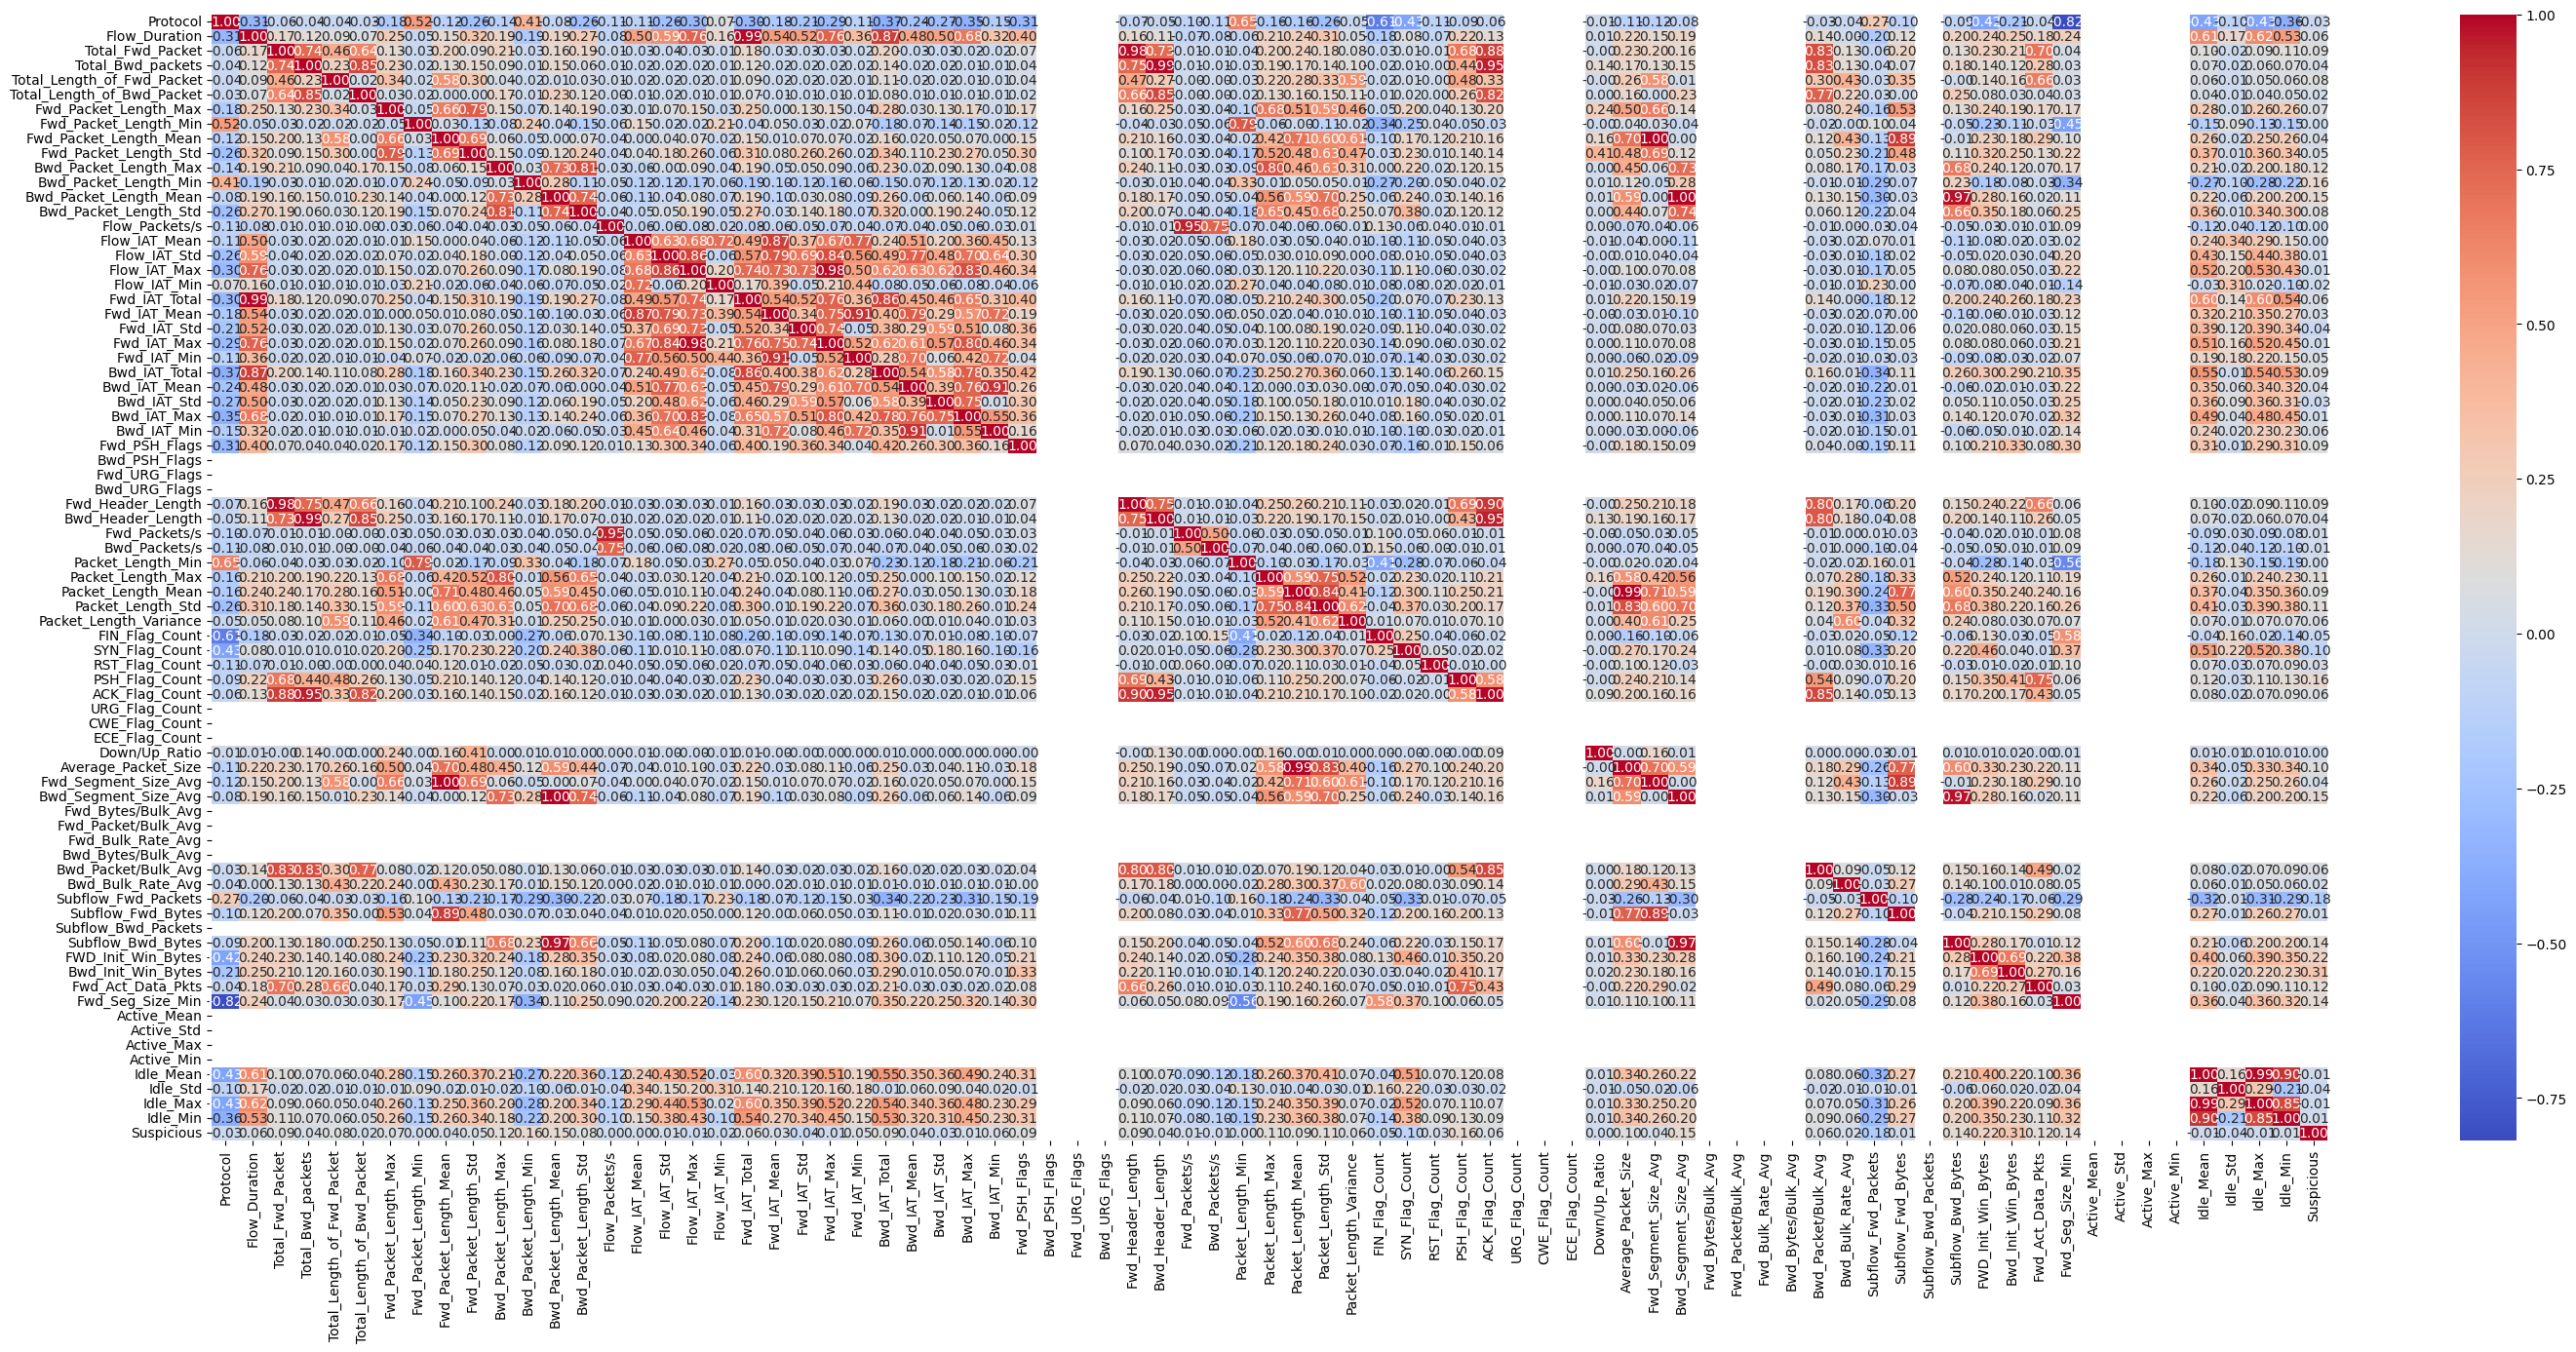

In [17]:
correlation_matrix = clean_data.corr()
plt.figure(figsize=(35,15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")


  Είναι  λογικό ότι δεν υπάρχουν features με υψηλο correlation με το suspicion
  που δημιουργήσαμε γιατί στην ουσία το feature  αυτό είναι το μόνο δυαδικό, ενώ τα περισσότερα από τα άλλα εμφανίζουν διάφορες τιμές. Βλέπουμε όμως 2 με >20% correlation.
  Το FWD_Init_Win_Bytes και το Bwd_Init_Win_Bytes Fwd Init Win bytes The total number of bytes sent in initial window in the forward direction Bwd Init Win bytes The total number of bytes sent in initial window in the backward direction




In [18]:
# FWD_Init_Win_Bytes Bwd_Init_Win_Bytes fainetai uparxei to megalutero correlation me to suspicious pou upologisame.
print('FWD_Init_Win_Bytes')
label1_fwdinitwinbytes = train_data.groupby('Label-1')['FWD_Init_Win_Bytes'].value_counts()['Tor'].head(10)
print(label1_fwdinitwinbytes)
print(train_data['FWD_Init_Win_Bytes'].value_counts()[65535])
# blepoume kai edw oti sxedon ola ta FWD_Init_Win_Bytes me timh 65535 einai apo xristes TOR. isws epeidh einai kapoio sunithes payload pou stelnei kapoio malware
# to idio paratiroume kai gia to Bwd_Init_Win_Bytes
print('Bwd_Init_Win_Bytes')
label1_bwdinitwinbytes = train_data.groupby('Label-1')['Bwd_Init_Win_Bytes'].value_counts()['Tor'].head(10)
print(label1_bwdinitwinbytes)
print(train_data['Bwd_Init_Win_Bytes'].value_counts()[65535])
# highlight oti ta perissotera 65535 anikoun se xristes Tor

FWD_Init_Win_Bytes
FWD_Init_Win_Bytes
65535    1078
0         100
14600      47
41180      23
41811      16
5989       12
443         9
526         7
3177        7
8192        7
Name: count, dtype: int64
1572
Bwd_Init_Win_Bytes
Bwd_Init_Win_Bytes
65535    1117
0         150
366        20
41811      13
5989        7
350         5
3177        5
5445        4
35838       4
358         3
Name: count, dtype: int64
1482


μπορούμε με ένα παρόμοιο transformer όπως από πάνω να προσθέσουμε και αυτα τα payload στα suspicious.

In [19]:
def sus_categorical_transformer(row):
    if row['Label-1'] == 'Tor':
        return 1
    if row['Src_Port'] in sus_ports:
        return 1
    if row['Dst_Port'] in sus_ports:
      return 1
    if row['Src_IP'] in sus_ips:
      if row['Label-2'] in tor_applications:
        return 1
    if row['Dst_IP'] in sus_ips:
      if row['Label-2'] in tor_applications:
        return 1
    if row['FWD_Init_Win_Bytes'] == 65535:
      return 1
    if row['Bwd_Init_Win_Bytes'] == 65535:
      return 1
    return 0

In [20]:
clean_data['Suspicious'] = train_data.apply(sus_categorical_transformer, axis=1)
# mporoume na kanoume drop kai auta ta columns twra
clean_data = clean_data.drop(['FWD_Init_Win_Bytes', 'Bwd_Init_Win_Bytes'], axis=1)
clean_data.info()
clean_data.groupby(['Suspicious']).size()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68580 entries, 0 to 68579
Data columns (total 75 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Protocol                    68580 non-null  int64  
 1   Flow_Duration               68580 non-null  int64  
 2   Total_Fwd_Packet            68580 non-null  int64  
 3   Total_Bwd_packets           68580 non-null  int64  
 4   Total_Length_of_Fwd_Packet  68580 non-null  int64  
 5   Total_Length_of_Bwd_Packet  68580 non-null  int64  
 6   Fwd_Packet_Length_Max       68580 non-null  int64  
 7   Fwd_Packet_Length_Min       68580 non-null  int64  
 8   Fwd_Packet_Length_Mean      68580 non-null  float64
 9   Fwd_Packet_Length_Std       68580 non-null  float64
 10  Bwd_Packet_Length_Max       68580 non-null  int64  
 11  Bwd_Packet_Length_Min       68580 non-null  int64  
 12  Bwd_Packet_Length_Mean      68580 non-null  float64
 13  Bwd_Packet_Length_Std       685

,0
Suspicious,
0,58575
1,10005


Σε αυτο το σημείο εχουμε ενα καλό clean dataset.Τώρα πρέπει να βρούμε ένα μοντέλο να το κάνουμε fit (train) και να κανουμε evaluate τα predictions του. Πόσο λάθος δηλαδη πέφτει από το target μας.


In [35]:
# train model
X_train = clean_data.drop(['Suspicious'], axis=1).reset_index(drop=True)
y_train = clean_data['Suspicious'].reset_index(drop=True)

In [42]:
# Now you can perform cross-validation
rfr_scores = -1 * cross_val_score(rfr_model, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')
#afto einai gia regressors alla tha to xrisimopoihsw ki as kanw classification giati ta sus mou einai 0 kai 1

σε future work, το σύστημά μας θα μπορούσε απ το να δίνει μόνο δυαδικά suspicious ή όχι μια σύνδεση, να δίνει το σκορ επικινδυνότητας. Εκεί θα χρησιμοποιούσαμε regressor.

τσεκάρω εάν υπάρχουν κάποια infinities που θα σπάσουν το μοντέλο.

In [37]:
X_train.columns.to_series()[np.isinf(X_train).any()]

,0
Flow_Packets/s,Flow_Packets/s


Βλέπουμε οτι το Flow_Packets/s έχει κάποια infinities οπότε καλό ειναι να τα αντικαταστήοσυμε με την μέγιστη τιμή που βρίσκουμε σε αυτό το feature, αφού πρώτα κάνουμε exclude τα infinities.

 Τσεκάρουμε για να βεβαιωθούμε οτι το x δεν έχει άλλα infinities.

In [38]:
flow_packets_max = X_train['Flow_Packets/s'][~np.isinf(X_train['Flow_Packets/s'])].max()
print(flow_packets_max)
X_train['Flow_Packets/s'].replace([np.inf, -np.inf], flow_packets_max, inplace=True)

X_train.columns.to_series()[np.isinf(X_train).any()]

3000000.0


<ipython-input-38-887cca2259c4>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Flow_Packets/s'].replace([np.inf, -np.inf], flow_packets_max, inplace=True)


,0


In [41]:
rf_classifier = RandomForestClassifier(n_estimators=1000, random_state=42)

rf_cross_val_scores = cross_val_score(rf_classifier, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", rf_cross_val_scores)
print("Mean Accuracy:", rf_cross_val_scores.mean())

Cross-Validation Scores: [0.89399242 0.93715369 0.9256343  0.93912219 0.75896763]
Mean Accuracy: 0.8909740449110528


 Τέλος θα κάνω fit το μοντέλο μου στα data.

In [43]:
# Fit the model to my training data
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)